# **Sesión 10 : Detección de Objetos**

---
Activa la GPU en *Entorno de ejecución ▷ Cambiar tipo de entorno de ejecución ▷ GPU* antes de empezar.

<a id='setup'></a>
## 1 · Setup – instalación y GPU

In [ ]:
!pip -q install ultralytics # Instalamos Ultralytics (nos permitirá usar YOLO)
import torch, platform, cv2, matplotlib
print(f'Torch {torch.__version__} · CUDA disponible:', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.2 MB/s eta 0:00:00
Torch 2.8.0+cu126 · CUDA disponible: True


<a id='conceptos'></a>
## 2 · Conceptos teóricos clave
**Detección de objetos** busca localizar y clasificar varias instancias de objetos en una imagen.

- *Bounding box* (x1, y1, x2, y2) con confianza y clase.  
- Métricas: IoU, mAP@0.5, mAP@[0.5:0.95].  
- Datasets típicos: COCO, Pascal VOC.  
- Dos familias populares:
  - **Two‑stage** (ej. Faster R‑CNN): primero propone regiones, luego refina.  
  - **One‑stage** (ej. YOLO, SSD): predice cajas directamente sobre una rejilla.

<a id='fasterrcnn'></a>
## 3 · Usando Faster R‑CNN (`torchvision`)

Esta función permitirá que probemos FasterR-CNN con nuestras imágenes

In [3]:
# Función utilitaria
def detect(img_path, score_th=0.5):
    # Leyendo imagen
    img = Image.open(img_path).convert('RGB')
    x = T.ToTensor()(img).to(device)
    # Detectando objetos en la imagen
    with torch.no_grad():
        out = model([x])[0] # Model es faster R-CNN

    # Usamos out para graficar los boxes sobre la imagen
    plt.figure(figsize=(6,6))
    plt.imshow(img); ax = plt.gca()
    for box, lbl, sc in zip(out['boxes'].cpu(), out['labels'].cpu(), out['scores'].cpu()):
      if sc < score_th:
        continue
      x1,y1,x2,y2 = box
      ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, ec='red', lw=2))
      ax.text(x1, y1, f'{class_names[lbl.item()]} {sc:.2f}', color='white', bbox=dict(fc='lime', alpha=0.5, lw=0))
    plt.axis('off'); plt.show()

print('La función detect() te permitirá probar con tu propia imagen')

La función detect() te permitirá probar con tu propia imagen


Descargemos el modelo Faster RCNN y también el nombre de las clases

In [4]:
import torchvision, torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn,
        FasterRCNN_ResNet50_FPN_Weights)

# Cargar modelo preentrenado y nombre de las clases (class_names)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
weights     = FasterRCNN_ResNet50_FPN_Weights.DEFAULT  # = COCO
class_names = weights.meta["categories"]
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()
print("Modelo cargado correctamente.")
print("Nombres de las clases: Listo.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 211MB/s]


Modelo cargado correctamente.
Nombres de las clases: Listo.


Usemos el modelo en nuestra imagen

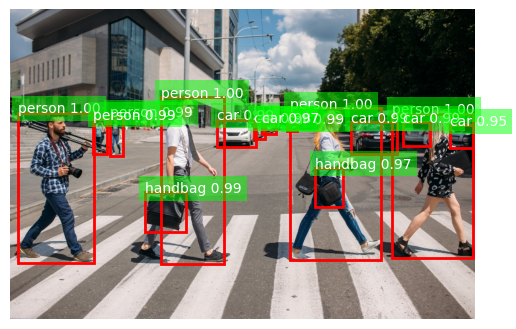

In [17]:
# Ejemplo (sube tu propia imagen al directorio que se encuentra allá <---)
detect('Sesion10_pedestrian.jpg', score_th=0.95) # Cambia el score de la confianza

<a id='yolov8'></a>
## 4 · Inferencia con YOLOv8 (`ultralytics`)

Carguemos YOLO usando ultralytics

In [27]:
from ultralytics import YOLO
# Cargar modelo nano (rápido)
yolo = YOLO('yolov8n.pt')

Usemos YOLO (recuerda que podemos cambiar la confianza)


image 1/1 /content/Sesion10_cuatro_mascotas.jpg: 352x640 3 dogs, 1 sheep, 8.4ms
Speed: 2.0ms preprocess, 8.4ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


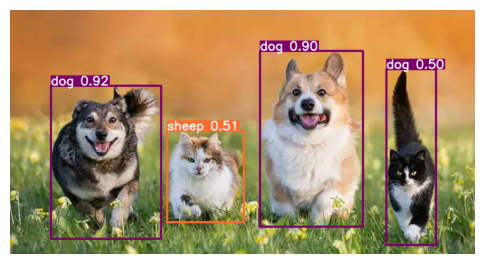

In [28]:
results = yolo('Sesion10_cuatro_mascotas.jpg', conf=0.5)  # Usa la misma ruta de tu imagen anterior

# Podemos mostrar los resultados asi:
# results[0].show()

# También podemos mostrar los resultados así:
im_bgr = results[0].plot()                 # numpy array BGR con cajas dibujadas
im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(im_rgb); plt.axis('off')
plt.show()

## Manden sus resultados por el chat indicando la confianza que han seleccionado
1. **Sube una foto** propia o de internet (personas, mascotas, escenas urbana).  
2. Ejecuta `detect()` (`fasterRCNN`) y `YOLO()` sobre la misma imagen.  
3. ¿Qué objetos detecta cada modelo? ¿Cuál tiene mejor confianza?  